In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from matplotlib.lines import Line2D
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# Подготовка набора данных

In [3]:
(penguins := pd.read_csv("penguins.csv"))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [4]:
penguins = penguins[penguins.bill_length_mm.notna()]
penguins[penguins.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [5]:
penguins = penguins.fillna("unknown")
penguins_adelie = penguins[penguins.species == "Adelie"]
penguins_gentoo = penguins[penguins.species == "Gentoo"]
penguins_chinstrap = penguins[penguins.species == "Chinstrap"]
label_male, label_female, label_unknown = "Самцы", "Самки", "Неизвестно"
hue_male, hue_female, hue_unknown = "male", "female", "unknown"
color_male, color_female, color_unknown = "#4c72b0", "#dd8452", "#55a868"
palette_sex = {hue_male: color_male, hue_female: color_female, hue_unknown: color_unknown}
marker_male = Line2D([], [], color=color_male, linestyle="None", marker=".", markersize=8)
marker_female = Line2D([], [], color=color_female, linestyle="None", marker=".", markersize=8)
marker_unknown = Line2D([], [], color=color_unknown, linestyle="None", marker=".", markersize=16)

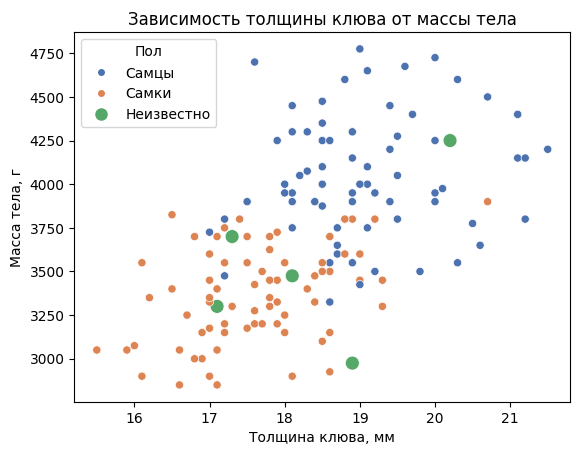

In [6]:
sns.scatterplot(
    penguins_adelie, x=penguins_adelie.bill_depth_mm, y=penguins_adelie.body_mass_g,
    hue="sex", size="sex",
    palette=palette_sex, hue_order=[hue_male, hue_female, hue_unknown], sizes=[35, 35, 100]
).set(
    title="Зависимость толщины клюва от массы тела", xlabel="Толщина клюва, мм", ylabel="Масса тела, г"
)
plt.legend(
    handles=[marker_male, marker_female, marker_unknown],
    labels=[label_male, label_female, label_unknown],
    title="Пол"
);

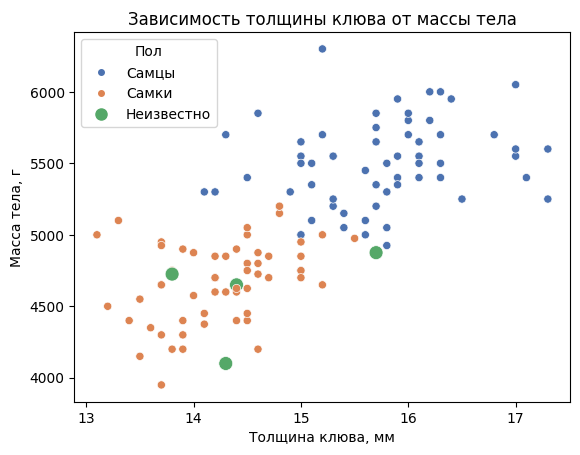

In [7]:
sns.scatterplot(
    penguins_gentoo, x=penguins_gentoo.bill_depth_mm, y=penguins_gentoo.body_mass_g,
    hue="sex", size="sex", palette=palette_sex,
    hue_order=[hue_male, hue_female, hue_unknown], sizes=[35, 35, 100]
).set(
    title="Зависимость толщины клюва от массы тела", xlabel="Толщина клюва, мм", ylabel="Масса тела, г"
)
plt.legend(
    handles=[marker_male, marker_female, marker_unknown],
    labels=[label_male, label_female, label_unknown],
    title="Пол"
);

In [8]:
penguins_adelie[penguins_adelie.sex == "unknown"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,unknown
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,unknown
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,unknown
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,unknown
47,Adelie,Dream,37.5,18.9,179.0,2975.0,unknown


In [9]:
penguins_gentoo[penguins_gentoo.sex == "unknown"]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,unknown
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,unknown
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,unknown
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,unknown


In [10]:
penguins_adelie.at[8, "sex"] = "female"
penguins_adelie.at[9, "sex"] = "male"
penguins_adelie.at[10, "sex"] = "female"
penguins_adelie.at[11, "sex"] = "female"
penguins_adelie.at[47, "sex"] = "female"
penguins_gentoo.at[178, "sex"] = "female"
penguins_gentoo.at[218, "sex"] = "female"
penguins_gentoo.at[256, "sex"] = "female"
penguins_gentoo.at[268, "sex"] = "male"

In [11]:
(penguins := pd.concat([penguins_adelie, penguins_gentoo, penguins_chinstrap]))

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [12]:
one_hot_encoder = OneHotEncoder()
encoded_species = one_hot_encoder.fit_transform(penguins[["species"]])
penguins[["adelie", "chinstrap", "gentoo"]] = encoded_species.toarray()
encoded_island = one_hot_encoder.fit_transform(penguins[["island"]])
penguins[["biscoe", "dream", "torgersen"]] = encoded_island.toarray()
penguins.drop(columns=["species", "island"], inplace=True)
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,male,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,female,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,female,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,female,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,male,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,male,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,female,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,male,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,male,0.0,1.0,0.0,0.0,1.0,0.0


In [13]:
penguins.sex = penguins.sex.map({"female": 0, "male": 1})
penguins

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,1,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,0,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,0,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,0,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,1,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,1,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,0,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,1,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,1,0.0,1.0,0.0,0.0,1.0,0.0


In [14]:
(y := penguins.sex)

0      1
1      0
2      0
4      0
5      1
      ..
339    1
340    0
341    1
342    1
343    0
Name: sex, Length: 342, dtype: int64

In [15]:
(X := penguins.drop(columns="sex"))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen
0,39.1,18.7,181.0,3750.0,1.0,0.0,0.0,0.0,0.0,1.0
1,39.5,17.4,186.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0
2,40.3,18.0,195.0,3250.0,1.0,0.0,0.0,0.0,0.0,1.0
4,36.7,19.3,193.0,3450.0,1.0,0.0,0.0,0.0,0.0,1.0
5,39.3,20.6,190.0,3650.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,0.0,1.0,0.0,0.0,1.0,0.0
340,43.5,18.1,202.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0
341,49.6,18.2,193.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0
342,50.8,19.0,210.0,4100.0,0.0,1.0,0.0,0.0,1.0,0.0


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Своя реализация дерева решений

In [17]:
class MyDecisionTreeClassifier:
    class Node:
        def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, value=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value
        
        def is_leaf(self):
            return self.value is not None
    
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2, min_samples_leaf=1):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        
        self.root = None
        self.n_classes_ = None
        self.n_features_in_ = None
        
        if self.criterion not in ["gini", "entropy"]:
            raise ValueError("Ошибка: недопустимое значение criterion")
    
    def __gini(self, y):
        counts = np.bincount(y)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)
    
    def __entropy(self, y):
        counts = np.bincount(y)
        probs = counts[counts > 0] / len(y)
        return -np.sum(probs * np.log2(probs))
    
    def __impurity(self, y):
        if len(y) == 0:
            return 0
        if self.criterion == "gini":
            return self.__gini(y)
        return self.__entropy(y)
    
    def __best_split(self, X, y):
        n_samples, n_features = X.shape
        best_gain = -float("inf")
        best_feature_index = None
        best_threshold = None
        
        if n_samples <= 1:
            return best_feature_index, best_threshold, best_gain
        
        current_impurity = self.__impurity(y)
        
        for feature_index in range(n_features):
            feature_values = np.unique(X[:, feature_index])
            
            thresholds = (feature_values[:-1] + feature_values[1:]) / 2
            
            for threshold in thresholds:
                left_mask = X[:, feature_index] <= threshold
                right_mask = ~left_mask
                
                y_left = y[left_mask]
                y_right = y[right_mask]
                
                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue
                
                left_impurity = self.__impurity(y_left)
                right_impurity = self.__impurity(y_right)
                n_left, n_right = len(y_left), len(y_right)
                
                weighted_impurity = (n_left * left_impurity + n_right * right_impurity) / n_samples
                
                gain = current_impurity - weighted_impurity
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature_index = feature_index
                    best_threshold = threshold
        
        return best_feature_index, best_threshold, best_gain
    
    def __build_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        
        if (self.max_depth is not None and depth >= self.max_depth or
            n_samples < self.min_samples_split or
            len(np.unique(y)) == 1):
            
            most_common = Counter(y).most_common(1)[0][0]
            return self.Node(value=most_common)
        
        best_feature, best_threshold, best_gain = self.__best_split(X, y)
        
        if best_feature is None or best_gain <= 0:
            most_common = Counter(y).most_common(1)[0][0]
            return self.Node(value=most_common)
        
        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask
        
        left_subtree = self.__build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.__build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return self.Node(feature_index=best_feature, threshold=best_threshold, left=left_subtree, right=right_subtree)
    
    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=int)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        self.n_features_in_ = X.shape[1]
        self.n_classes_ = len(np.unique(y))
        
        self.root = self.__build_tree(X, y)
        
        return self
    
    def __predict_sample(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature_index] <= node.threshold:
            return self.__predict_sample(x, node.left)
        else:
            return self.__predict_sample(x, node.right)
    
    def predict(self, X):
        if self.root is None:
            raise ValueError("Ошибка: перед предсказанием нужно обучить модель")
        
        X = np.array(X, dtype=float)
        
        if X.ndim == 1:
            X = X.reshape(-1, 1)
        
        if X.shape[1] != self.n_features_in_:
            raise ValueError(f"Ошибка: ожидается {self.n_features_in_} признаков, а получено {X.shape[1]}")
        
        preds = [self.__predict_sample(x, self.root) for x in X]
        return np.array(preds)
    
    def predict_proba(self, X):
        preds = self.predict(X)
        proba = np.zeros((len(preds), self.n_classes_))
        for i, pred in enumerate(preds):
            proba[i, pred] = 1.0
        return proba
    
    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y, dtype=int)
        return np.mean(y_pred == y_true).item()

# Сравнение библиотечной реализации со своей

In [18]:
tree1 = DecisionTreeClassifier(criterion="entropy", random_state=5)
tree1.fit(X_train, y_train)
tree1.score(X_test, y_test)

0.912621359223301

In [19]:
tree2 = MyDecisionTreeClassifier(criterion="entropy")
tree2.fit(X_train, y_train)
tree2.score(X_test, y_test)

0.912621359223301

In [20]:
tree1.predict_proba(X_test[:10])

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.]])

In [21]:
tree2.predict_proba(X_test[:10])

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.]])

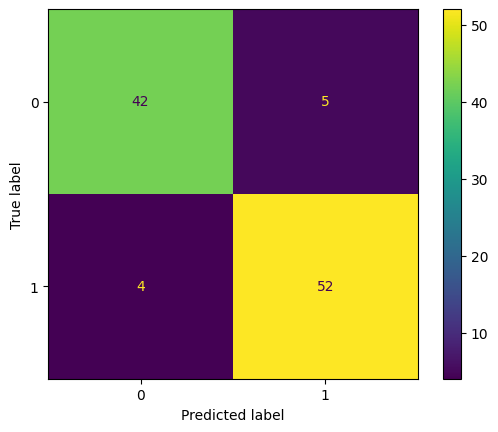

In [22]:
y_tree1 = tree1.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_tree1);

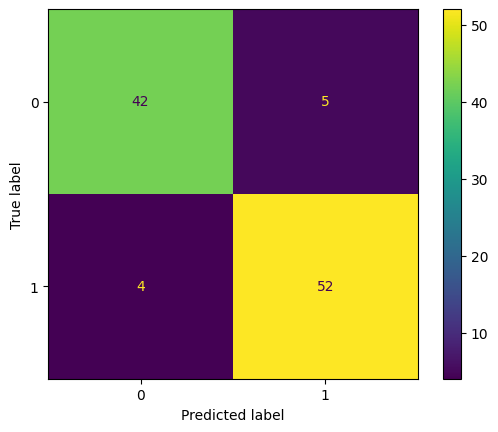

In [23]:
y_tree2 = tree2.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_tree2);

In [26]:
pd.concat([X_test[y_test != y_tree1], y_test[y_test != y_tree1]], axis=1).sort_index()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen,sex
1,39.5,17.4,186.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0,0
21,37.7,18.7,180.0,3600.0,1.0,0.0,0.0,1.0,0.0,0.0,1
22,35.9,19.2,189.0,3800.0,1.0,0.0,0.0,1.0,0.0,0.0,0
82,36.7,18.8,187.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0,0
114,39.6,20.7,191.0,3900.0,1.0,0.0,0.0,1.0,0.0,0.0,0
121,37.7,19.8,198.0,3500.0,1.0,0.0,0.0,0.0,0.0,1.0,1
141,40.6,17.2,187.0,3475.0,1.0,0.0,0.0,0.0,1.0,0.0,1
297,48.5,17.5,191.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0,1
343,50.2,18.7,198.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0,0


In [27]:
pd.concat([X_test[y_test != y_tree2], y_test[y_test != y_tree2]], axis=1).sort_index()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,adelie,chinstrap,gentoo,biscoe,dream,torgersen,sex
1,39.5,17.4,186.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0,0
21,37.7,18.7,180.0,3600.0,1.0,0.0,0.0,1.0,0.0,0.0,1
22,35.9,19.2,189.0,3800.0,1.0,0.0,0.0,1.0,0.0,0.0,0
82,36.7,18.8,187.0,3800.0,1.0,0.0,0.0,0.0,0.0,1.0,0
114,39.6,20.7,191.0,3900.0,1.0,0.0,0.0,1.0,0.0,0.0,0
121,37.7,19.8,198.0,3500.0,1.0,0.0,0.0,0.0,0.0,1.0,1
141,40.6,17.2,187.0,3475.0,1.0,0.0,0.0,0.0,1.0,0.0,1
297,48.5,17.5,191.0,3400.0,0.0,1.0,0.0,0.0,1.0,0.0,1
343,50.2,18.7,198.0,3775.0,0.0,1.0,0.0,0.0,1.0,0.0,0
